In [13]:
from pyhgf.model import Network
from jax.typing import ArrayLike
from scipy.stats import halfnorm, norm
import jax
import jax.numpy as jnp
from jax import random
from jax.tree_util import Partial
from jax import vmap
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import time

In [14]:
def generate_observations(
    n_nodes, n_steps, scenario=1, shock_pattern=None,
    shock_time=None, recovery_time=None, trend_shape="linear"
):
    np.random.seed(42)  # Fix seed for reproducibility
    node_observations = []

    # Par défaut, les paramètres beta pour les nœuds
    phase1_params = (5, 1)
    phase2_params = (2, 2)
    phase3_params = phase1_params

    def generate_beta(params, size):
        return np.random.beta(a=params[0], b=params[1], size=size)

    for node in range(n_nodes):
        # Scenario 1: Stable observations
        if scenario == 1:
            node_observations.append(generate_beta(phase1_params, n_steps))

        # Scenario 2: Shock scenarios
        elif scenario == 2:
            shock_time = shock_time or n_steps // 3
            recovery_time = recovery_time or 2 * n_steps // 3
            if shock_pattern in [None, "phase"]:
                phase1_end, phase2_end = (shock_time, recovery_time) if recovery_time else (n_steps // 3, 2 * n_steps // 3)
                obs = np.concatenate([generate_beta(phase1_params, phase1_end),
                                      generate_beta(phase2_params, phase2_end - phase1_end),
                                      generate_beta(phase3_params, n_steps - phase2_end)])
            elif shock_pattern == "sudden":
                obs = np.concatenate([generate_beta(phase1_params, shock_time),
                                      generate_beta(phase2_params, recovery_time - shock_time),
                                      generate_beta(phase3_params, n_steps - recovery_time)])
            elif shock_pattern == "trend":
                obs = np.zeros(n_steps)
                for t in range(recovery_time):
                    weight = (t / recovery_time) if trend_shape == "linear" else (t / recovery_time)**2
                    alpha = phase1_params[0] * (1 - weight) + phase2_params[0] * weight
                    beta_param = phase1_params[1] * (1 - weight) + phase2_params[1] * weight
                    obs[t] = generate_beta((alpha, beta_param), 1)
                for t in range(recovery_time, n_steps):
                    weight = 1 - ((t - recovery_time) / (n_steps - recovery_time)) if trend_shape == "linear" else (1 - (t - recovery_time) / (n_steps - recovery_time))**2
                    alpha = phase2_params[0] * (1 - weight) + phase1_params[0] * weight
                    beta_param = phase2_params[1] * (1 - weight) + phase1_params[1] * weight
                    obs[t] = generate_beta((alpha, beta_param), 1)
            else:
                raise ValueError("Invalid shock_pattern specified for scenario 2.")

            node_observations.append(obs)

        else:
            raise ValueError("Scenario must be 1 or 2.")

    return np.column_stack(node_observations)


In [15]:
def calculate_kl_divergence(mu_belief, prec_belief, mean_pref, precision_pref):
    """
    Calculate the KL divergence between two Gaussian distributions.

    Args:
        mu_belief: Mean of the belief distribution.
        prec_belief: Precision of the belief distribution.
        mean_pref: Mean of the preference distribution.
        precision_pref: Precision of the preference distribution.

    Returns:
        KL divergence.
    """
    # Convert precision to variance
    var_belief = jnp.where(prec_belief > 0, 1 / prec_belief, jnp.inf)
    var_pref = jnp.where(precision_pref > 0, 1 / precision_pref, jnp.inf)

    # Calculate KL divergence using the analytical formula for Gaussian distributions
    kl = jnp.log(jnp.sqrt(var_pref) / jnp.sqrt(var_belief)) + \
         (var_belief + (mu_belief - mean_pref) ** 2) / (2 * var_pref) - 0.5

    return kl

In [16]:
def get_votes(tonic_volatility: float, key: random.PRNGKey, network: Network, input_data: ArrayLike) -> Network:

    # Initialize the last node's attributes if not already present
    network.attributes[-1]['preferences'] = []

    # Loop to sample and store tuples
    for pref in range(n_preferences):
        mu = norm.rvs(2, 1)
        sigma = halfnorm.rvs(0, 1)
        network.attributes[-1]['preferences'].append((np.float64(mu), np.float64(sigma)))

    # Set different parameters for this agent
    network.attributes[3]["tonic_volatility"] = tonic_volatility
    network.attributes[4]["tonic_volatility"] = tonic_volatility
    network.attributes[5]["tonic_volatility"] = tonic_volatility

    network.input_data(input_data=input_data)  # add observations

    # get the preferences from the last node of the network
    preferences = network.attributes[-1].get("preferences", [])
    start_index = len(preferences) // 2
    mean_pref = jnp.array([float(pref[0]) for pref in preferences])
    precision_pref = jnp.array([float(pref[1]) for pref in preferences])

    # get the beliefs from the network
    start_index = len(preferences)  # ou une autre formule basée sur l'astuce
    mu_belief = jnp.array([network.node_trajectories[i + start_index]["expected_mean"][-1] for i in range(len(preferences))])
    prec_belief = jnp.array([network.node_trajectories[i + start_index]["expected_precision"][-1] for i in range(len(preferences))])

    # Calculate the current dissatisfaction in a vectorized manner
    current_dissatisfaction = calculate_kl_divergence(mu_belief, prec_belief, mean_pref, precision_pref)
    total_current_dissatisfaction = jnp.sum(current_dissatisfaction)

    # Initialize a list to store the voting decisions for each candidate
    candidate_preferences = []

    # For each candidate, calculate the expected dissatisfaction in a vectorized manner
    for idx, candidate in enumerate(candidates):
        candidate_mean_pref = jnp.array([float(preference[0]) for preference in candidate])
        candidate_precision_pref = jnp.array([float(preference[1]) for preference in candidate])
        # Calculate the expected dissatisfaction for this candidate in a vectorized manner
        expected_dissatisfaction = calculate_kl_divergence(mu_belief, prec_belief, candidate_mean_pref, candidate_precision_pref)
        total_expected_dissatisfaction = jnp.sum(expected_dissatisfaction)
        candidate_preferences.append(total_current_dissatisfaction - total_expected_dissatisfaction)

    # Convert candidate_preferences to JAX array
    candidate_preferences = jnp.array(candidate_preferences)
    # Softmax of candidate_preferences to get probabilities
    softmax_probs = jax.nn.softmax(candidate_preferences)
    # log of softmax_probs for the voting distribution
    log_softmax_probs = jnp.log(softmax_probs)
    vote_decisions = random.categorical(key, log_softmax_probs)

    # Update the network attributes with the vote decisions
    network.attributes[-1]["votes"] = vote_decisions

    return network.attributes, network.node_trajectories

In [17]:
import numpy as np
from scipy.stats import norm, halfnorm

# Paramètres
n_candidates = 6 # nombre de candidats
n_preferences = 3  # nombre de préférences par candidat
n_extreme_candidates = 2  # nombre de candidats extrêmes

# Choisir aléatoirement quels candidats seront extrêmes
extreme_indices = np.random.choice(n_candidates, n_extreme_candidates, replace=False)
candidates = []

for i in range(n_candidates):
    preferences = []
    if i in extreme_indices:
        # Pour les candidats extrêmes, le degré d'extrémisme est variable
        extremism_factor = np.random.uniform(1.5, 3)  # facteur entre 1.5 et 3
        mu_sigma = extremism_factor  # augmente l'écart-type de mu
        sigma_scale = extremism_factor  # augmente l'échelle de sigma
    else:
        mu_sigma = 1
        sigma_scale = 1

    for pref in range(n_preferences):
        mu = norm.rvs(2, mu_sigma)
        sigma = halfnorm.rvs(scale=sigma_scale)
        mu_sigma_tuple = (np.float64(mu), np.float64(sigma))
        preferences.append(mu_sigma_tuple)

    candidates.append(tuple(preferences))

print("Contenu de candidates:")
print(candidates)


Contenu de candidates:
[((np.float64(-0.8890936654283674), np.float64(3.3809544084008327)), (np.float64(7.415263982872751), np.float64(0.476390252652712)), (np.float64(2.487718066526875), np.float64(1.7059983368281553))), ((np.float64(2.7978026730494165), np.float64(1.1263668609956057)), (np.float64(2.7840331804651037), np.float64(0.10606190903803867)), (np.float64(3.2219971209735023), np.float64(1.0712541496927257))), ((np.float64(2.0058523367253764), np.float64(1.5637356160497993)), (np.float64(0.7497535018796806), np.float64(0.677475656997163)), (np.float64(2.671747291077291), np.float64(0.39391197323615235))), ((np.float64(0.6849944697440358), np.float64(0.592083003564623)), (np.float64(1.3810994907176732), np.float64(2.1709095648954997)), (np.float64(-0.4966037578411786), np.float64(0.04365206539589439))), ((np.float64(3.075314139359355), np.float64(0.5376896974278628)), (np.float64(2.303444750924045), np.float64(0.7342609171767251)), (np.float64(1.0066217944161435), np.float64(0.

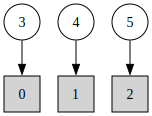

In [18]:
# Create agent preferences
network = (
    Network()
    .add_nodes(kind="binary-state", n_nodes=n_preferences)
    .add_nodes(value_children=0)
    .add_nodes(value_children=1)
    .add_nodes(value_children=2)
)
network.plot_network()

In [19]:
input_data = generate_observations(n_nodes=3, n_steps=1000, scenario=2, shock_pattern="sudden",shock_time=600, recovery_time=990)
n_agents = 100
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)
simulations = 100
proportions = []

while simulations > 0:
    key = random.PRNGKey(int(time.time()))
    keys = random.split(key, n_agents)
    get_votes_fn = Partial(
        get_votes,
        network=copy.deepcopy(network),
        input_data=input_data
    )

    vmap_get_votes_fn = vmap(get_votes_fn)
    attribute, nodes_traje = vmap_get_votes_fn(tonic_volatilities, keys)
    attribute[-1]["votes"]
    proportions.append(attribute[-1]["votes"])
    simulations = simulations - 1

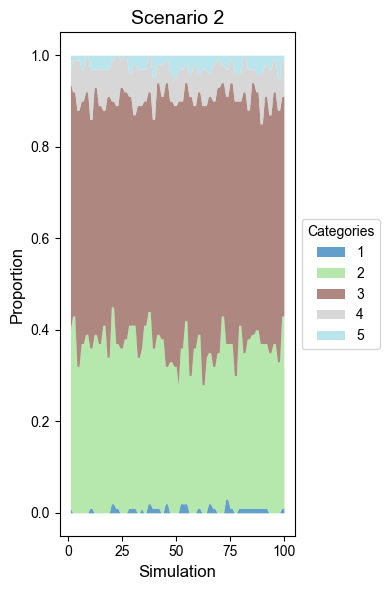

In [20]:
# Préparer les données pour le graphique
df = pd.DataFrame({
    'Simulation': np.repeat(np.arange(1, len(proportions) + 1), [len(p) for p in proportions]),
    'Category': np.concatenate([p for p in proportions])
})

# Calculer les proportions par catégorie et simulation
category_proportions = df.groupby(['Simulation', 'Category']).size().unstack(fill_value=0)
category_proportions = category_proportions.div(category_proportions.sum(axis=1), axis=0)  # Normalisation

category_proportions.plot(kind='area', stacked=True, figsize=(4, 6), colormap='tab20', alpha=0.7, linewidth=0)

plt.xlabel('Simulation', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.title('Scenario 2', fontsize=14)
plt.legend(title='Categories', loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


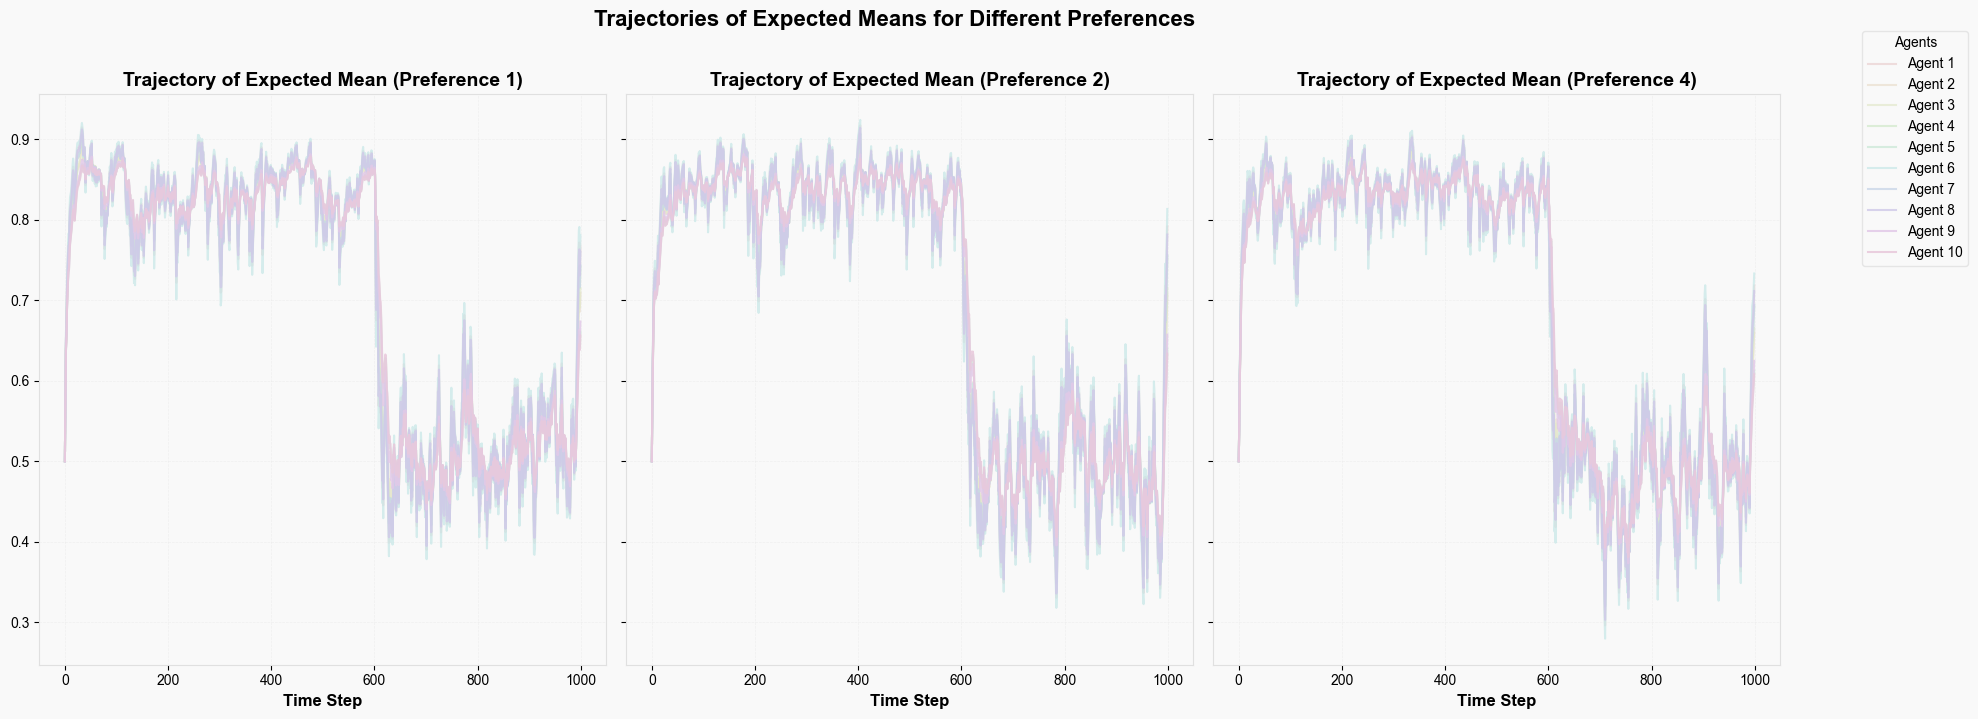

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import colorsys

# Définir les paramètres globaux pour la police
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Définir les styles de ligne (tous des traits pleins)
line_styles = ["-"] * 10  # Tous les styles de ligne sont des traits pleins

# Créer une figure avec 3 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True, facecolor='#f9f9f9')

# Liste des préférences et leurs indices correspondants
preferences = [0, 1, 2]  # Indices pour pref 1, pref 2, pref 4
pref_labels = ['Preference 1', 'Preference 2', 'Preference 4']

# Générer une palette de couleurs pastel
def generate_pastel_colors(n):
    pastel_colors = []
    for i in range(n):
        hue = i / n  # Distribuer les teintes uniformément
        saturation = 0.4  # Saturation légèrement réduite pour des couleurs encore plus pastel
        lightness = 0.85  # Luminosité plus élevée pour des couleurs très claires
        rgb = colorsys.hls_to_rgb(hue, lightness, saturation)
        pastel_colors.append(rgb)
    return pastel_colors

pastel_colors = generate_pastel_colors(10)

for idx, pref in enumerate(preferences):
    ax = axes[idx]
    ax.set_facecolor('#f9f9f9')  # Fond du graphique légèrement plus clair
    for n_agent in range(10):
        # Utiliser la couleur pastel correspondante
        color = pastel_colors[n_agent]
        # Définir la transparence
        alpha = 0.6 + 0.3 * (n_agent / 10)  # Variantes de transparence
        ax.plot(
            nodes_traje[pref]["expected_mean"][n_agent],
            label=f'Agent {n_agent + 1}' if idx == 0 else "",
            color=color,
            linestyle=line_styles[n_agent % len(line_styles)],
            linewidth=1.5,  # Lignes un peu plus fines
            alpha=alpha
        )
    ax.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax.set_title(f'Trajectory of Expected Mean ({pref_labels[idx]})', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0', linewidth=0.5)  # Grille très subtile

    # Ajouter une bordure subtile autour de chaque sous-graphique
    for spine in ax.spines.values():
        spine.set_edgecolor('#e0e0e0')  # Couleur de bordure très claire
        spine.set_linewidth(0.8)

# Ajouter une légende commune
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1), title="Agents", facecolor='#f9f9f9', edgecolor='#e0e0e0')

# Ajouter un titre global
fig.suptitle('Trajectories of Expected Means for Different Preferences', fontsize=16, fontweight='bold', y=1.02)

# Ajuster les marges et l'espacement
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Ajustement pour le titre global

plt.show()


In [22]:
#input_data = np.random.uniform(0, 1, size=(3, 100)).astype(float).T
input_data = generate_observations(n_nodes=3, n_steps=100, scenario=1)
n_agents = 100
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)
simulations = 100
proportions = []

while simulations > 0:
    key = random.PRNGKey(int(time.time()))
    keys = random.split(key, n_agents)
    get_votes_fn = Partial(
        get_votes,
        network=copy.deepcopy(network),
        input_data=input_data
    )

    vmap_get_votes_fn = vmap(get_votes_fn)
    attribute, nodes_traje = vmap_get_votes_fn(tonic_volatilities, keys)
    attribute[-1]["votes"]
    proportions.append(attribute[-1]["votes"])
    simulations = simulations - 1

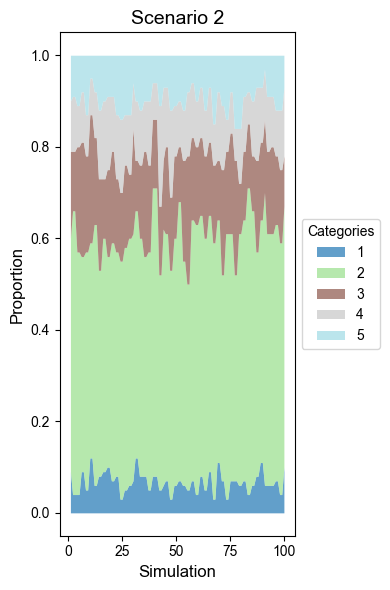

In [23]:
# Préparer les données pour le graphique
df = pd.DataFrame({
    'Simulation': np.repeat(np.arange(1, len(proportions) + 1), [len(p) for p in proportions]),
    'Category': np.concatenate([p for p in proportions])
})

# Calculer les proportions par catégorie et simulation
category_proportions = df.groupby(['Simulation', 'Category']).size().unstack(fill_value=0)
category_proportions = category_proportions.div(category_proportions.sum(axis=1), axis=0)  # Normalisation
category_proportions.plot(kind='area', stacked=True, figsize=(4, 6), colormap='tab20', alpha=0.7, linewidth=0)

plt.xlabel('Simulation', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.title('Scenario 2', fontsize=14)
plt.legend(title='Categories', loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


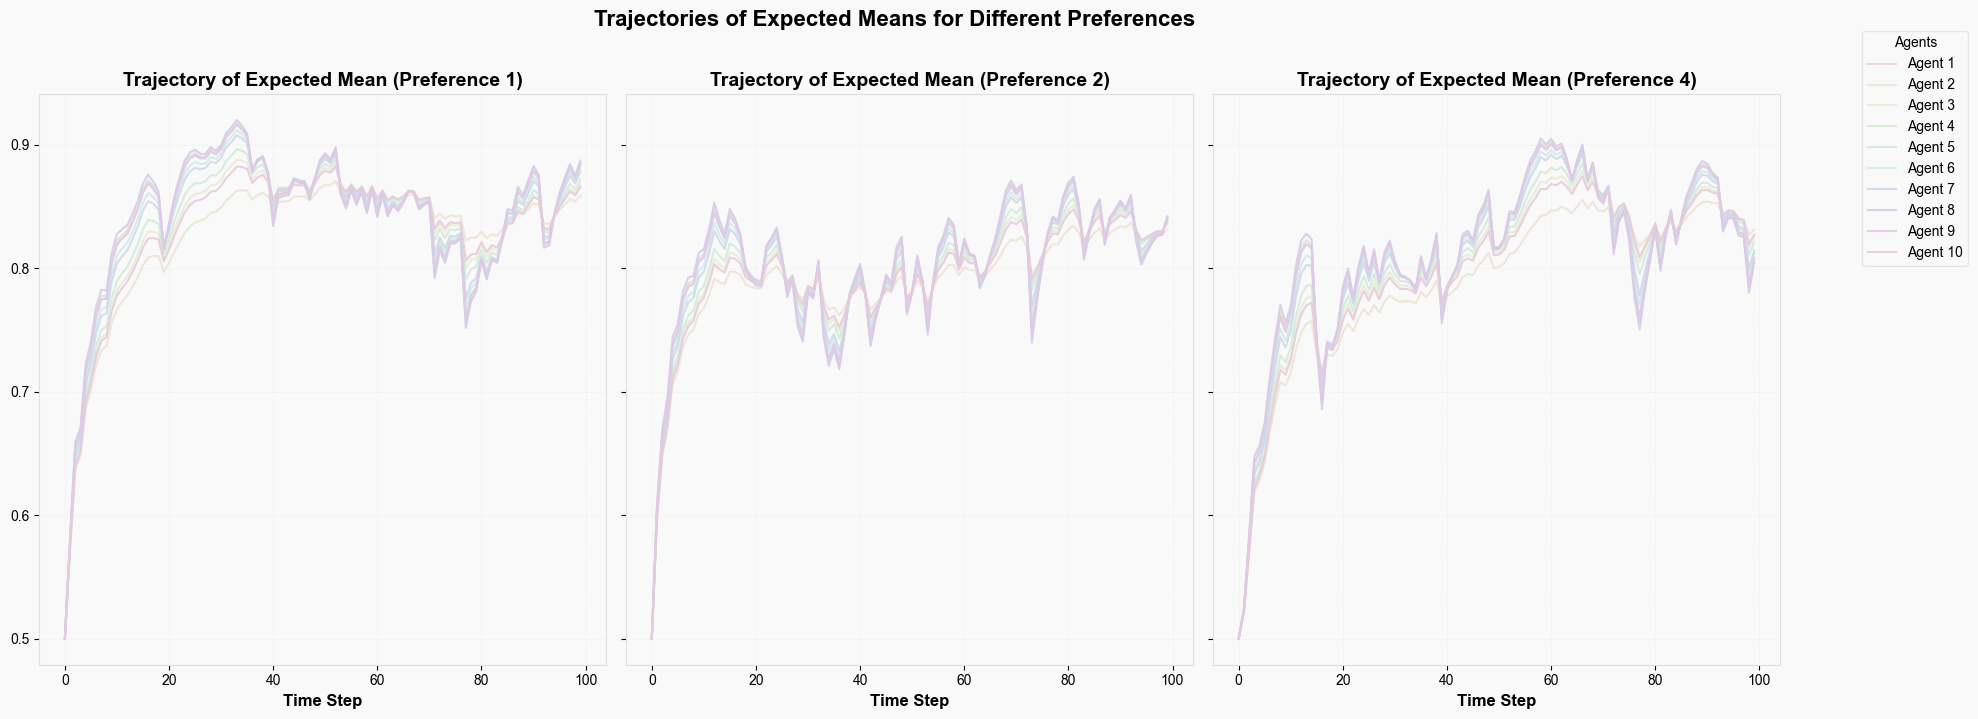

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import colorsys

# Définir les paramètres globaux pour la police
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Définir les styles de ligne (tous des traits pleins)
line_styles = ["-"] * 10  # Tous les styles de ligne sont des traits pleins

# Créer une figure avec 3 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True, facecolor='#f9f9f9')

# Liste des préférences et leurs indices correspondants
preferences = [0, 1, 2]  # Indices pour pref 1, pref 2, pref 4
pref_labels = ['Preference 1', 'Preference 2', 'Preference 4']

# Générer une palette de couleurs pastel
def generate_pastel_colors(n):
    pastel_colors = []
    for i in range(n):
        hue = i / n  # Distribuer les teintes uniformément
        saturation = 0.4  # Saturation légèrement réduite pour des couleurs encore plus pastel
        lightness = 0.85  # Luminosité plus élevée pour des couleurs très claires
        rgb = colorsys.hls_to_rgb(hue, lightness, saturation)
        pastel_colors.append(rgb)
    return pastel_colors

pastel_colors = generate_pastel_colors(10)

for idx, pref in enumerate(preferences):
    ax = axes[idx]
    ax.set_facecolor('#f9f9f9')  # Fond du graphique légèrement plus clair
    for n_agent in range(10):
        # Utiliser la couleur pastel correspondante
        color = pastel_colors[n_agent]
        # Définir la transparence
        alpha = 0.6 + 0.3 * (n_agent / 10)  # Variantes de transparence
        ax.plot(
            nodes_traje[pref]["expected_mean"][n_agent],
            label=f'Agent {n_agent + 1}' if idx == 0 else "",
            color=color,
            linestyle=line_styles[n_agent % len(line_styles)],
            linewidth=1.5,  # Lignes un peu plus fines
            alpha=alpha
        )
    ax.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax.set_title(f'Trajectory of Expected Mean ({pref_labels[idx]})', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0', linewidth=0.5)  # Grille très subtile

    # Ajouter une bordure subtile autour de chaque sous-graphique
    for spine in ax.spines.values():
        spine.set_edgecolor('#e0e0e0')  # Couleur de bordure très claire
        spine.set_linewidth(0.8)

# Ajouter une légende commune
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1), title="Agents", facecolor='#f9f9f9', edgecolor='#e0e0e0')

# Ajouter un titre global
fig.suptitle('Trajectories of Expected Means for Different Preferences', fontsize=16, fontweight='bold', y=1.02)

# Ajuster les marges et l'espacement
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Ajustement pour le titre global

plt.show()
